# Saving Waveforms as WAV Files for LTspice

**Scott Prahl**

**Mar 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import os
import matplotlib.pyplot as plt
from RigolWFM import Wfm

repo = "https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/"

## Introduction

A measured waveform captured on a Rigol oscilloscope can be exported as a `.wav` file and used directly as a voltage or current source in an LTspice simulation.  This lets you drive a simulated circuit with a real measured signal — a captured input pulse, a noisy power rail, or an RF envelope — without having to hand-fit a piecewise-linear (PWL) approximation.

The advantages of `.wav` over `.txt`/PWL are:

* **Compact** — 2 bytes per sample versus ~20 bytes per line of PWL text (10× smaller)
* **Fast to load** — binary format, no text parsing in LTspice
* **Multi-channel** — a single stereo WAV file can carry two independent signals

## WAV File Format

RigolWFM writes **signed 16-bit PCM** WAV files (the standard CD-audio sample format).  Each sample is a 16-bit integer in the range −32767 to +32767.  LTspice normalises this range to [−1, +1] and then multiplies by `Vpeak` to recover physical voltages.

### Voltage Scaling

The `scale` parameter controls how scope voltages are mapped to integers:

| `scale` | Mapping | LTspice `Vpeak` to set |
|---------|---------|------------------------|
| `"auto"` *(default)* | signal min → −32767, signal max → +32767 | `(v_max − v_min) / 2` |
| `"scope"` | −4×V/div → −32767, +4×V/div → +32767; **zero stays at zero** | `4 × V/div` |

Use `"auto"` when only the shape matters (e.g. a frequency-domain stimulus).  Use `"scope"` when the DC level is important and you want zero volts to remain zero in the simulation.

### Mono vs. Stereo

A mono WAV carries one channel; a stereo WAV carries two, interleaved as left/right audio frames.  LTspice selects the channel with the `chan=` parameter (zero-based: `chan=0` = first channel, `chan=1` = second).

## Using a WAV File in LTspice

Voltage and current sources in LTspice accept a `wavefile=` attribute:

```
Vxxx  n+  n-  wavefile="<filename>"  [chan=<n>]  Vpeak=<volts>
Ixxx  n+  n-  wavefile="<filename>"  [chan=<n>]  Vpeak=<amps>
```

* `<filename>` is an absolute path, or a relative path from the schematic directory.
* `chan=` selects the channel (default 0).  Only meaningful for stereo files.
* `Vpeak` scales the normalised [−1, +1] range to physical units.
* This source is only active during a `.tran` analysis.

### Example: RC Low-Pass Filter Driven by a Measured Waveform

Suppose you have captured a noisy 5 kHz square wave on CH1 (2 V/div) and saved it as `signal.wav` using `scale="scope"` (so `Vpeak = 4 × 2 = 8 V`):

```spice
* RC low-pass filter — input from measured waveform
V1  in  0  wavefile="signal.wav"  Vpeak=8
R1  in  out  1k
C1  out  0   10n
.tran  0  3.3ms
.backanno
.end
```

To add the source in the LTspice GUI: right-click the voltage source → **Advanced** → in the **"Value"** field enter `wavefile="signal.wav" Vpeak=8`.

### Example: Two-Channel Stimulus from a Stereo WAV

If the `.wav` was saved with `channel=[1, 2]`, both scope channels live in one file:

```spice
* Two independent stimulus signals from one stereo WAV
V1  sig1  0  wavefile="stereo.wav"  chan=0  Vpeak=8
V2  sig2  0  wavefile="stereo.wav"  chan=1  Vpeak=20
```

## API Reference

```python
wfm.wav(filename, *, channel=1, scale="auto")
```

* **`filename`** — output path (string, `os.PathLike`, or a writable binary file object)
* **`channel`** — scope channel number(s) to export.  An `int` gives a mono file; a two-element `list` gives a stereo file (e.g. `[1, 2]`).
* **`scale`** — `"auto"` or `"scope"` (see table above)

A `ValueError` is raised if the requested channel is not enabled or more than two channels are specified.

## Example Waveform

Load a two-channel DS1102E capture from the project repository.

In [2]:
stem = "DS1102E-D"
w = Wfm.from_url(repo + stem + ".wfm?raw=true", "E")
print(w.describe())

    General:
        File Model   = DS1000E
        User Model   = E
        Parser Model = wfm1000e
        Firmware     = unknown
        Filename     = DS1102E-D.wfm
        Channels     = [1, 2]

    Trigger:
        Mode     = edge
        Source   = CH1
        Level    = 1.60  V
        Sweep    = AUTO
        Coupling = DC
        Derived Level     = -1.20  V

     Channel 1:
         Coupling =  unknown
            Scale =     2.00  V/div
           Offset =     2.40  V
            Probe =       1X
         Inverted =    False

        Time Base =  100.000 µs/div
           Offset =    0.000  s
            Delta =  400.000 ns/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [       41,       41,       41  ...       110,      110]
           Times  = [-1.638 ms,-1.638 ms,-1.638 ms  ...  1.638 ms, 1.638 ms]
           Volts  = [  4.32  V,  4.32  V,  4.32  V  ...  -1.20  V, -1.20  V]

     Channel

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1102E-D.wfm?raw=true'


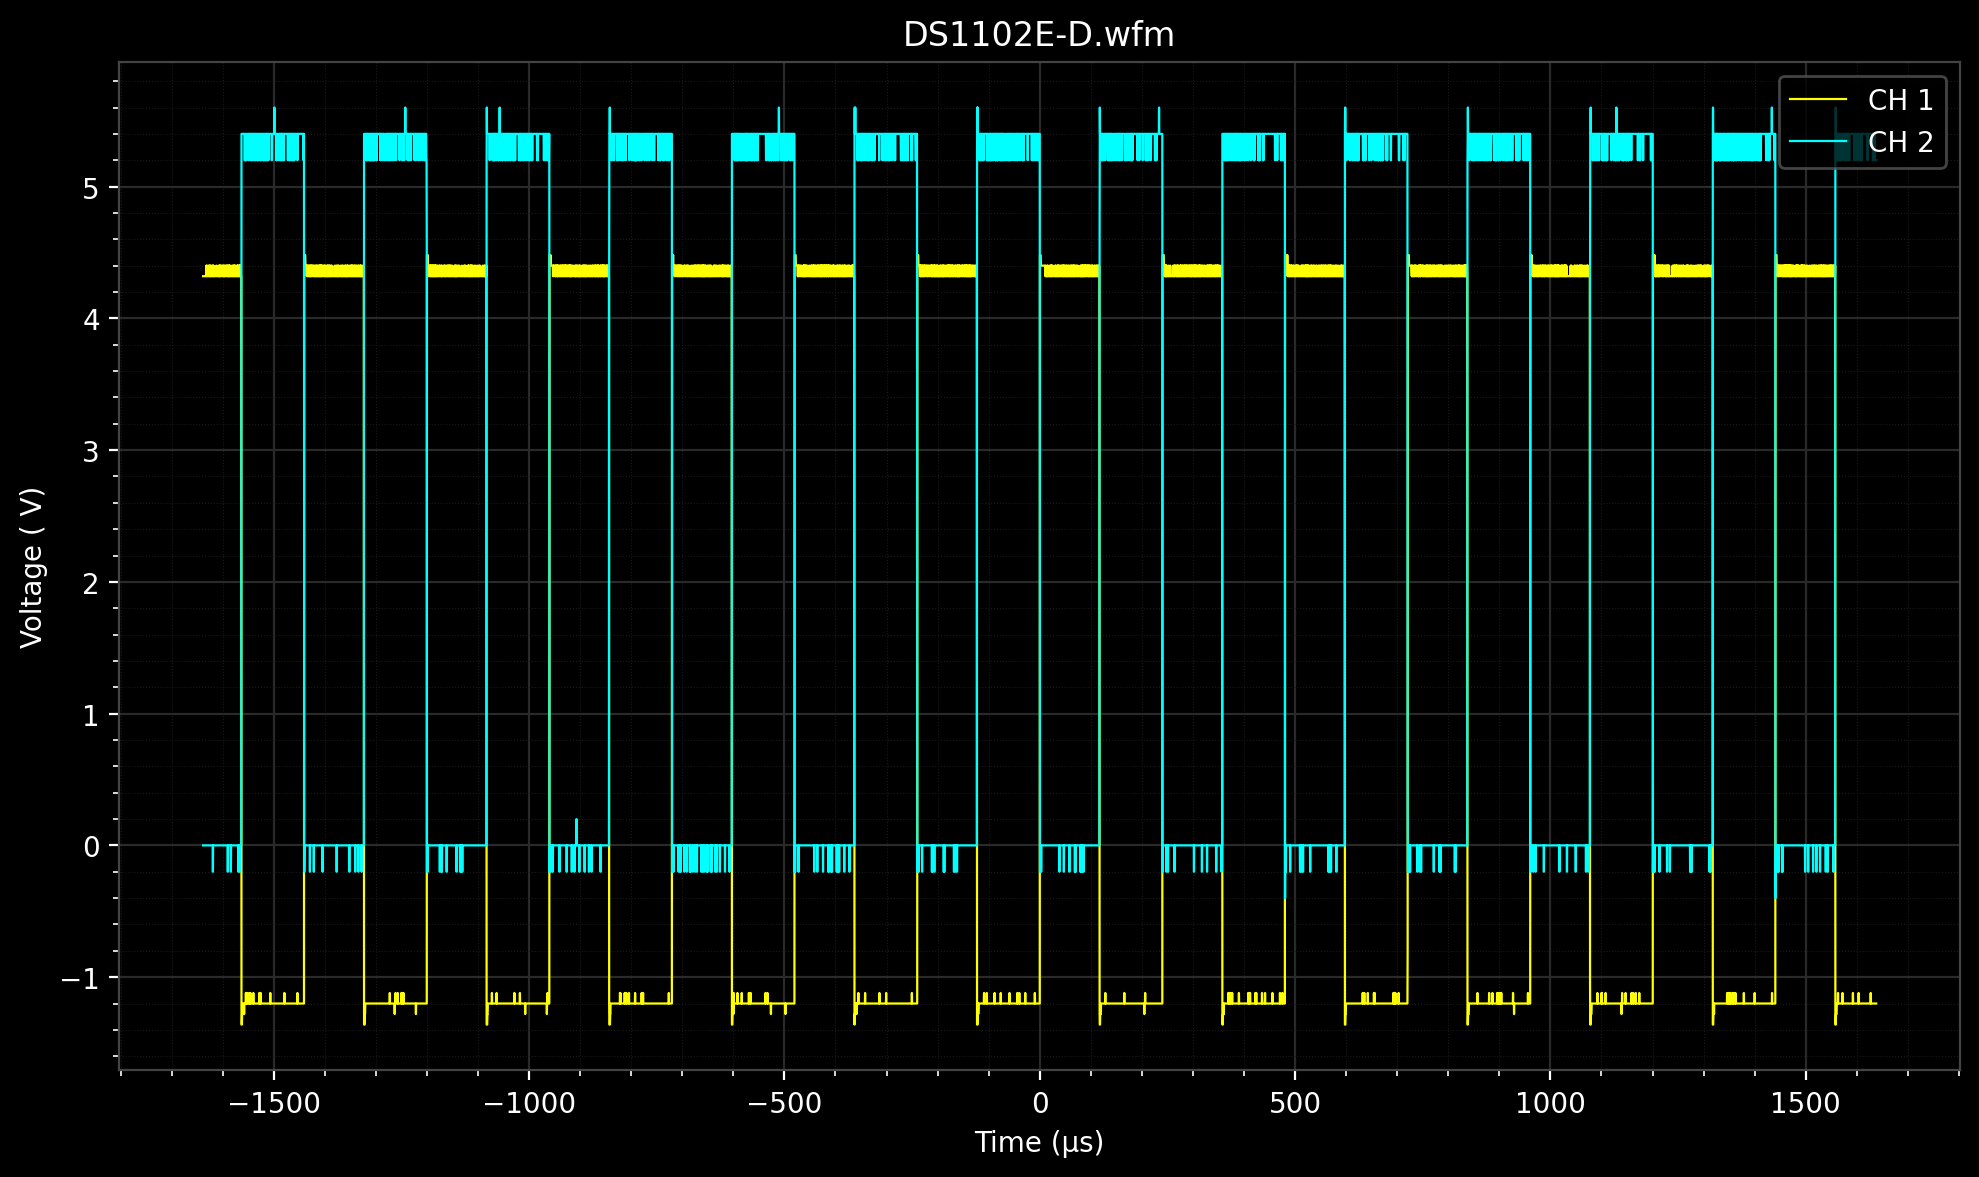

In [3]:
w.plot()
plt.show()

## Mono WAV — `scale="auto"`

The signal's own voltage range is mapped to ±32767.  The waveform shape is preserved but the DC level is lost.  To reconstruct the original amplitude in LTspice, set `Vpeak` to half the peak-to-peak voltage of the signal.

For CH1 in this capture the voltage swings from about −1.2 V to 4.3 V, so the peak-to-peak is ≈ 5.5 V and `Vpeak ≈ 2.76 V`.

In [4]:
import numpy as np

ch1 = next(c for c in w.channels if c.channel_number == 1)
v_min, v_max = float(np.min(ch1.volts)), float(np.max(ch1.volts))
vpeak_auto = (v_max - v_min) / 2
print(f"CH1 voltage range: {v_min:.3f} V  to  {v_max:.3f} V")
print(f"LTspice Vpeak for scale='auto': {vpeak_auto:.3f} V")

wav_auto = stem + "_auto.wav"
w.wav(wav_auto, channel=1, scale="auto")
print(f"Written: {wav_auto}  ({os.path.getsize(wav_auto)} bytes)")

CH1 voltage range: -1.360 V  to  4.480 V
LTspice Vpeak for scale='auto': 2.920 V
Written: DS1102E-D_auto.wav  (16428 bytes)


LTspice netlist entry for this file:

```spice
V1  in  0  wavefile="DS1102E-D_auto.wav"  Vpeak=2.76
```

## Mono WAV — `scale="scope"`

The scope's full-scale range (±4 × V/div) is mapped to ±32767.  Zero volts stays at zero, so the DC level is preserved.  Set `Vpeak = 4 × V/div` in LTspice.

CH1 is set to 2 V/div, so the full-scale range is ±8 V and `Vpeak = 8 V`.

In [5]:
vpeak_scope = 4 * ch1.volt_per_division
print(f"CH1 V/div: {ch1.volt_per_division:.2f} V")
print(f"LTspice Vpeak for scale='scope': {vpeak_scope:.2f} V")

wav_scope = stem + "_scope.wav"
w.wav(wav_scope, channel=1, scale="scope")
print(f"Written: {wav_scope}  ({os.path.getsize(wav_scope)} bytes)")

CH1 V/div: 2.00 V
LTspice Vpeak for scale='scope': 8.00 V
Written: DS1102E-D_scope.wav  (16428 bytes)


LTspice netlist entry for this file:

```spice
V1  in  0  wavefile="DS1102E-D_scope.wav"  Vpeak=8
```

## Stereo WAV — Two Channels in One File

Pass a two-element list to `channel` to write both scope channels into a single stereo WAV.  In LTspice, `chan=0` selects CH1 and `chan=1` selects CH2.

In [6]:
ch2 = next(c for c in w.channels if c.channel_number == 2)
vpeak_ch1 = 4 * ch1.volt_per_division
vpeak_ch2 = 4 * ch2.volt_per_division
print(f"CH1 V/div = {ch1.volt_per_division:.2f} V  →  Vpeak = {vpeak_ch1:.2f} V")
print(f"CH2 V/div = {ch2.volt_per_division:.2f} V  →  Vpeak = {vpeak_ch2:.2f} V")

wav_stereo = stem + "_stereo.wav"
w.wav(wav_stereo, channel=[1, 2], scale="scope")
print(f"Written: {wav_stereo}  ({os.path.getsize(wav_stereo)} bytes)")

CH1 V/div = 2.00 V  →  Vpeak = 8.00 V
CH2 V/div = 5.00 V  →  Vpeak = 20.00 V
Written: DS1102E-D_stereo.wav  (32812 bytes)


LTspice netlist entries for the stereo file:

```spice
V1  sig1  0  wavefile="DS1102E-D_stereo.wav"  chan=0  Vpeak=8
V2  sig2  0  wavefile="DS1102E-D_stereo.wav"  chan=1  Vpeak=20
```

## Command-Line Usage

The `wfmconvert` command-line tool can also produce WAV files.  The `--channel` flag selects one or two channels; `--scale` sets the voltage mapping.

```bash
# Mono WAV from CH1, auto scaling
wfmconvert --channel 1 wav DS1102E-D.wfm

# Mono WAV from CH1, scope scaling
wfmconvert --channel 1 --scale scope wav DS1102E-D.wfm

# Stereo WAV from CH1 and CH2
wfmconvert --channel 12 wav DS1102E-D.wfm
```

In [7]:
# Clean up generated WAV files
for f in [wav_auto, wav_scope, wav_stereo]:
    if os.path.exists(f):
        os.remove(f)